In [580]:
import numpy as np
import pandas as pd
import os
DATA_PATH = DATA_PATH = "/Users/aprillin/Library/CloudStorage/Box-Box/WHT Datasets/01_columns_synced/RealWorldHAR/PROBAND 13/walking.csv"
print(os.path.exists(DATA_PATH))

False


In [590]:
DATA_PATH = "/Users/aprillin/Library/CloudStorage/Box-Box/WHT Datasets/01_columns_synced/RealWorldHAR/PROBAND 5/jumping.csv"

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
df.head()

Shape: (4789, 36)


,PELVIS_GYR_X,PELVIS_GYR_Y,PELVIS_GYR_Z,PELVIS_ACC_X,PELVIS_ACC_Y,PELVIS_ACC_Z,L_FOREARM_GYR_X,L_FOREARM_GYR_Y,L_FOREARM_GYR_Z,L_FOREARM_ACC_X,...,L_SHANK_GYR_Z,L_SHANK_ACC_X,L_SHANK_ACC_Y,L_SHANK_ACC_Z,L_ARM_GYR_X,L_ARM_GYR_Y,L_ARM_GYR_Z,L_ARM_ACC_X,L_ARM_ACC_Y,L_ARM_ACC_Z
0,0.012217,-0.006600,0.028697,9.970653,-0.277129,0.991798,-0.007401,-0.020752,-0.003952,-9.51431,...,-0.013744,-1.094150,9.956287,-0.466869,-0.018937,0.018021,0.000611,-0.683545,10.118495,0.772729
1,0.013744,-0.008738,0.028392,9.963470,-0.263362,0.995988,-0.010605,-0.018616,0.003525,-9.50539,...,-0.017410,-1.121085,9.966463,-0.475848,-0.014966,0.008858,-0.000305,-0.685340,10.129868,0.764947
2,0.021991,-0.008738,0.027476,9.934740,-0.276530,0.987010,-0.015945,-0.020752,0.012070,-9.52864,...,-0.015882,-1.066018,9.988609,-0.480636,-0.008858,0.006414,-0.002443,-0.699705,10.111312,0.769137
3,0.029016,-0.006295,0.027476,9.928156,-0.272939,0.991798,-0.019150,-0.017548,0.013138,-9.54372,...,-0.012828,-1.069011,9.951499,-0.478840,-0.008552,0.003665,-0.000916,-0.691924,10.130465,0.771532
4,0.029322,0.000425,0.029003,9.928755,-0.301071,0.989404,-0.017014,-0.010071,0.018478,-9.55353,...,-0.012523,-1.082179,9.983223,-0.479439,-0.010385,-0.008247,0.003665,-0.677559,10.129269,0.798466


In [591]:
COL_PATTERNS = dict(
    acc=("{p}_ACC_X","{p}_ACC_Y","{p}_ACC_Z"),
    gyr=("{p}_GYR_X","{p}_GYR_Y","{p}_GYR_Z"),
)

# Find prefixes
prefixes = sorted({c.replace("_ACC_X","") for c in df.columns if c.endswith("_ACC_X")})
print("Auto-detected prefixes:", prefixes)

def build_sensors_from_prefixes(df, prefixes, patterns):
    cols = set(df.columns)
    sensors = {}
    for p in prefixes:
        acc_cols = tuple(s.format(p=p) for s in patterns["acc"])
        if not all(c in cols for c in acc_cols):
            continue

        gyr_cols = tuple(s.format(p=p) for s in patterns.get("gyr", ()))
        gyr_ok = len(gyr_cols) == 3 and all(c in cols for c in gyr_cols)

        sensors[p] = {"acc": acc_cols, "gyr": gyr_cols if gyr_ok else None}
    return sensors

SENSORS = build_sensors_from_prefixes(df, prefixes, COL_PATTERNS)
print("\nDetected sensors:", list(SENSORS.keys()))
for k,v in SENSORS.items():
    print(k, "->", v)


Auto-detected prefixes: ['HEAD', 'L_ARM', 'L_FOREARM', 'L_SHANK', 'PELVIS', 'TRUNK']

Detected sensors: ['HEAD', 'L_ARM', 'L_FOREARM', 'L_SHANK', 'PELVIS', 'TRUNK']
HEAD -> {'acc': ('HEAD_ACC_X', 'HEAD_ACC_Y', 'HEAD_ACC_Z'), 'gyr': ('HEAD_GYR_X', 'HEAD_GYR_Y', 'HEAD_GYR_Z')}
L_ARM -> {'acc': ('L_ARM_ACC_X', 'L_ARM_ACC_Y', 'L_ARM_ACC_Z'), 'gyr': ('L_ARM_GYR_X', 'L_ARM_GYR_Y', 'L_ARM_GYR_Z')}
L_FOREARM -> {'acc': ('L_FOREARM_ACC_X', 'L_FOREARM_ACC_Y', 'L_FOREARM_ACC_Z'), 'gyr': ('L_FOREARM_GYR_X', 'L_FOREARM_GYR_Y', 'L_FOREARM_GYR_Z')}
L_SHANK -> {'acc': ('L_SHANK_ACC_X', 'L_SHANK_ACC_Y', 'L_SHANK_ACC_Z'), 'gyr': ('L_SHANK_GYR_X', 'L_SHANK_GYR_Y', 'L_SHANK_GYR_Z')}
PELVIS -> {'acc': ('PELVIS_ACC_X', 'PELVIS_ACC_Y', 'PELVIS_ACC_Z'), 'gyr': ('PELVIS_GYR_X', 'PELVIS_GYR_Y', 'PELVIS_GYR_Z')}
TRUNK -> {'acc': ('TRUNK_ACC_X', 'TRUNK_ACC_Y', 'TRUNK_ACC_Z'), 'gyr': ('TRUNK_GYR_X', 'TRUNK_GYR_Y', 'TRUNK_GYR_Z')}


In [592]:
G0 = 9.80665 

def find_static_window(acc, gyr=None, win=300, step=50):
    """Best-effort low-motion window. Uses gyro if present; otherwise accel variance only."""
    acc = np.asarray(acc, float)
    N = len(acc)
    if N <= win:
        return 0, N

    def acc_stability(a):
        return float(np.mean(np.std(a, axis=0)))

    if gyr is not None:
        gyr = np.asarray(gyr, float)
        gyr_mag = np.linalg.norm(gyr, axis=1)
        def score(s,e):
            return float(np.mean(gyr_mag[s:e]) + 0.5*acc_stability(acc[s:e]))
    else:
        def score(s,e):
            return float(acc_stability(acc[s:e]))

    best = (np.inf, 0, win)
    for s in range(0, N-win+1, step):
        e = s + win
        sc = score(s,e)
        if sc < best[0]:
            best = (sc, s, e)
    return best[1], best[2]

def detect_accel_units_and_scale(acc_static):
    """Detect accel units and return a factor to multiply by to get units of g."""
    acc_static = np.asarray(acc_static, float)
    mag = np.linalg.norm(acc_static, axis=1)
    med = float(np.median(mag))

    # already in g (~1)
    if 0.3 <= med <= 2.5:
        return {"unit_label":"g", "scale_to_g":1.0, "median_mag":med}

    # in m/s^2 (~9.81)
    if 6.0 <= med <= 14.0:
        return {"unit_label":"m/s^2", "scale_to_g":1.0/G0, "median_mag":med}

    # raw counts / scaled ints: estimate counts_per_g from static magnitude
    counts_per_g = med  # if static magnitude corresponds to ~1g
    scale = 1.0 / counts_per_g
    return {"unit_label":"raw", "scale_to_g":scale, "median_mag":med, "counts_per_g_est":counts_per_g}

def normalize(v, eps=1e-14):
    v = np.asarray(v, float)
    n = np.linalg.norm(v)
    if n < eps:
        raise ValueError("Cannot normalize near-zero vector")
    return v / n

def rot_between(a, b):
    """Rotation matrix R such that R @ a ≈ b (Rodrigues)."""
    a = normalize(a); b = normalize(b)
    v = np.cross(a, b)
    c = float(np.clip(np.dot(a, b), -1.0, 1.0))
    s = np.linalg.norm(v)

    if s < 1e-14:
        if c > 0:
            return np.eye(3)
        # 180° flip about any axis orthogonal to a
        tmp = np.array([1,0,0]) if abs(a[0]) < 0.9 else np.array([0,1,0])
        axis = normalize(np.cross(a, tmp))
        K = np.array([[0,-axis[2],axis[1]],
                      [axis[2],0,-axis[0]],
                      [-axis[1],axis[0],0]])
        return np.eye(3) + 2*(K@K)

    K = np.array([[0,-v[2],v[1]],
                  [v[2],0,-v[0]],
                  [-v[1],v[0],0]])
    R = np.eye(3) + K + (K@K) * ((1 - c) / (s**2))
    return R

def rotate_series(R, V):
    V = np.asarray(V, float)
    return (R @ V.T).T

def angle_deg(u, v):
    u = normalize(u); v = normalize(v)
    c = float(np.clip(np.dot(u, v), -1.0, 1.0))
    return float(np.degrees(np.arccos(c)))

def rot_y(theta):
    """Rotation matrix about Y axis (right-hand rule). Used to fix heading (forward) in horizontal plane."""
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, 0, s], [0, 1, 0], [-s, 0, c]])


In [597]:
# ── Fixed analytic rotation matrices (from RealWorldHAR pic documentation) ─────────────
# v_isb = R @ v_sensor   (columns of R = sensor local axes in ISB)
#
# Body sensors (HEAD, L_ARM, L_SHANK, TRUNK): X=right, Y=up (toward screen top), Z=outward from screen
#   ISB X = -sensor Z  (front    = -backward)
#   ISB Y = -sensor Y  (up       =  up)
#   ISB Z =  sensor X  (right    = -left)
R_Body = np.array([
    [0, 0, -1],
    [0, -1, 0],
    [1, 0, 0]
], dtype=float)

# Forearm sensors
#   target X = -sensor Z  
#   target Y = sensor X  
#   target Z = sensor Y  
R_FOREARM = np.array([
    [0, -1, 0],
    [1,  0, 0],
    [0,  0, 1]
], dtype=float)

R_HEAD = np.array([
    [0, -1, 0],
    [1,  0, 0],
    [0,  0, 1]
], dtype=float)

R_SHANK = np.array([
    [1,  0,  0],
    [0, -1,  0],
    [0,  0, -1]
], dtype=float)

R_UPPERARM = np.array([
    [1,  0,  0],
    [0, -1,  0],
    [0,  0, -1]
], dtype=float)

# Pelvis sensors
#   target X =  sensor Z  
#   target Y = -sensor X  
#   target Z =  sensor Y  
R_PELVIS = np.array([
    [0,  1, 0],
    [-1, 0, 0],
    [0,  0, 1]
], dtype=float)

R_TRUNK = np.array([
    [1,  0,  0],
    [0, -1,  0],
    [0,  0, -1]
], dtype=float)

R_Correct=np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1]
], dtype=float)



ROTATIONS = {
    "HEAD": R_HEAD,
    "L_FOREARM": R_FOREARM,
    "L_SHANK": R_SHANK,
    "L_UPPERARM": R_UPPERARM,
    "PELVIS": R_PELVIS,
    "TRUNK": R_TRUNK
}

ROTATE_GYRO = True
STATIC_WIN  = 300
STATIC_STEP = 50

df_out   = df.copy()
report   = []
rotations = {}          # R_isb_from_sensor for each sensor

# Cast sensor columns to float64 (raw data is int; rotation produces floats)
for _s, _m in SENSORS.items():
    for _col in _m["acc"]:
        df_out[_col] = df_out[_col].astype("float64")
    if ROTATE_GYRO and _m.get("gyr") is not None:
        for _col in _m["gyr"]:
            df_out[_col] = df_out[_col].astype("float64")

ISB_DOWN = np.array([0., -1., 0.])

for s, m in SENSORS.items():
    acc_cols = m["acc"]
    gyr_cols = m["gyr"]

    acc_raw = df.loc[:, acc_cols].to_numpy(float)
    gyr_raw = df.loc[:, gyr_cols].to_numpy(float) if gyr_cols is not None else None

    # 1) Detect units and scale to g
    ws, we = find_static_window(acc_raw, gyr=gyr_raw,
                                win=min(STATIC_WIN, len(df)), step=STATIC_STEP)
    info  = detect_accel_units_and_scale(acc_raw[ws:we])
    scale = float(info["scale_to_g"])
    acc_g = acc_raw * scale

    # 2) Fixed analytic rotation
    R = ROTATIONS.get(s, R_Body)  
    rotations[s] = R

    # 3) Apply rotation to accelerometer
    acc_isb = rotate_series(R, acc_g)
    df_out.loc[:, acc_cols[0]] = acc_isb[:, 0]
    df_out.loc[:, acc_cols[1]] = acc_isb[:, 1]
    df_out.loc[:, acc_cols[2]] = acc_isb[:, 2]

    # 4) Apply same rotation to gyroscope (axis-only, no unit scaling)
    if ROTATE_GYRO and gyr_raw is not None:
        gyr_isb = rotate_series(R, gyr_raw)
        df_out.loc[:, gyr_cols[0]] = gyr_isb[:, 0]
        df_out.loc[:, gyr_cols[1]] = gyr_isb[:, 1]
        df_out.loc[:, gyr_cols[2]] = gyr_isb[:, 2]

    # 5) Validation: gravity in static window should be ~[0, -1, 0] after rotation
    g_after   = np.mean(acc_isb[ws:we], axis=0)
    ang_after = angle_deg(g_after, ISB_DOWN)  # should be ~0 deg

    report.append({
        "sensor":              s,
        "static_start":        ws,
        "static_end":          we,
        "detected_unit":       info["unit_label"],
        "scale_to_g":          scale,
        "gravity_angle_after_deg": ang_after,
    })

report_df = pd.DataFrame(report).sort_values("sensor")
report_df


,sensor,static_start,static_end,detected_unit,scale_to_g,gravity_angle_after_deg
0,HEAD,0,300,m/s^2,0.101972,9.826362
1,L_ARM,0,300,m/s^2,0.101972,18.619432
2,L_FOREARM,0,300,m/s^2,0.101972,18.237298
3,L_SHANK,0,300,m/s^2,0.101972,6.606683
4,PELVIS,0,300,m/s^2,0.101972,2.731491
5,TRUNK,0,300,m/s^2,0.101972,4.021849


In [585]:
DATA_PATH_csv = "/Users/aprillin/Library/CloudStorage/Box-Box/WHT Datasets/02_coords_synced/RealWorldHAR/PROBAND 14/"
os.makedirs(DATA_PATH_csv, exist_ok=True)

output_path = os.path.join(DATA_PATH_csv, "jumping.csv")
df_out.to_csv(output_path, index=False)

print(output_path)

/Users/aprillin/Library/CloudStorage/Box-Box/WHT Datasets/02_coords_synced/RealWorldHAR/PROBAND 14/jumping.csv


In [598]:
for row in report:
    s = row["sensor"]
    ws, we = int(row["static_start"]), int(row["static_end"])
    ax, ay, az = SENSORS[s]["acc"]
    gmean = df_out.loc[ws:we-1, [ax,ay,az]].to_numpy(float).mean(axis=0)
    print(f"{s}: mean accel in static (g) [X,Y,Z] = {gmean}")


HEAD: mean accel in static (g) [X,Y,Z] = [ 0.03364665 -0.91944337 -0.15565613]
L_ARM: mean accel in static (g) [X,Y,Z] = [-0.15405457 -0.87055869  0.24958863]
L_FOREARM: mean accel in static (g) [X,Y,Z] = [ 0.20073407 -0.84757075 -0.19417099]
L_SHANK: mean accel in static (g) [X,Y,Z] = [-0.08585632 -1.01382834  0.08010641]
PELVIS: mean accel in static (g) [X,Y,Z] = [ 0.00551615 -1.00390606 -0.04757731]
TRUNK: mean accel in static (g) [X,Y,Z] = [-0.01995036 -0.97891094  0.0658724 ]


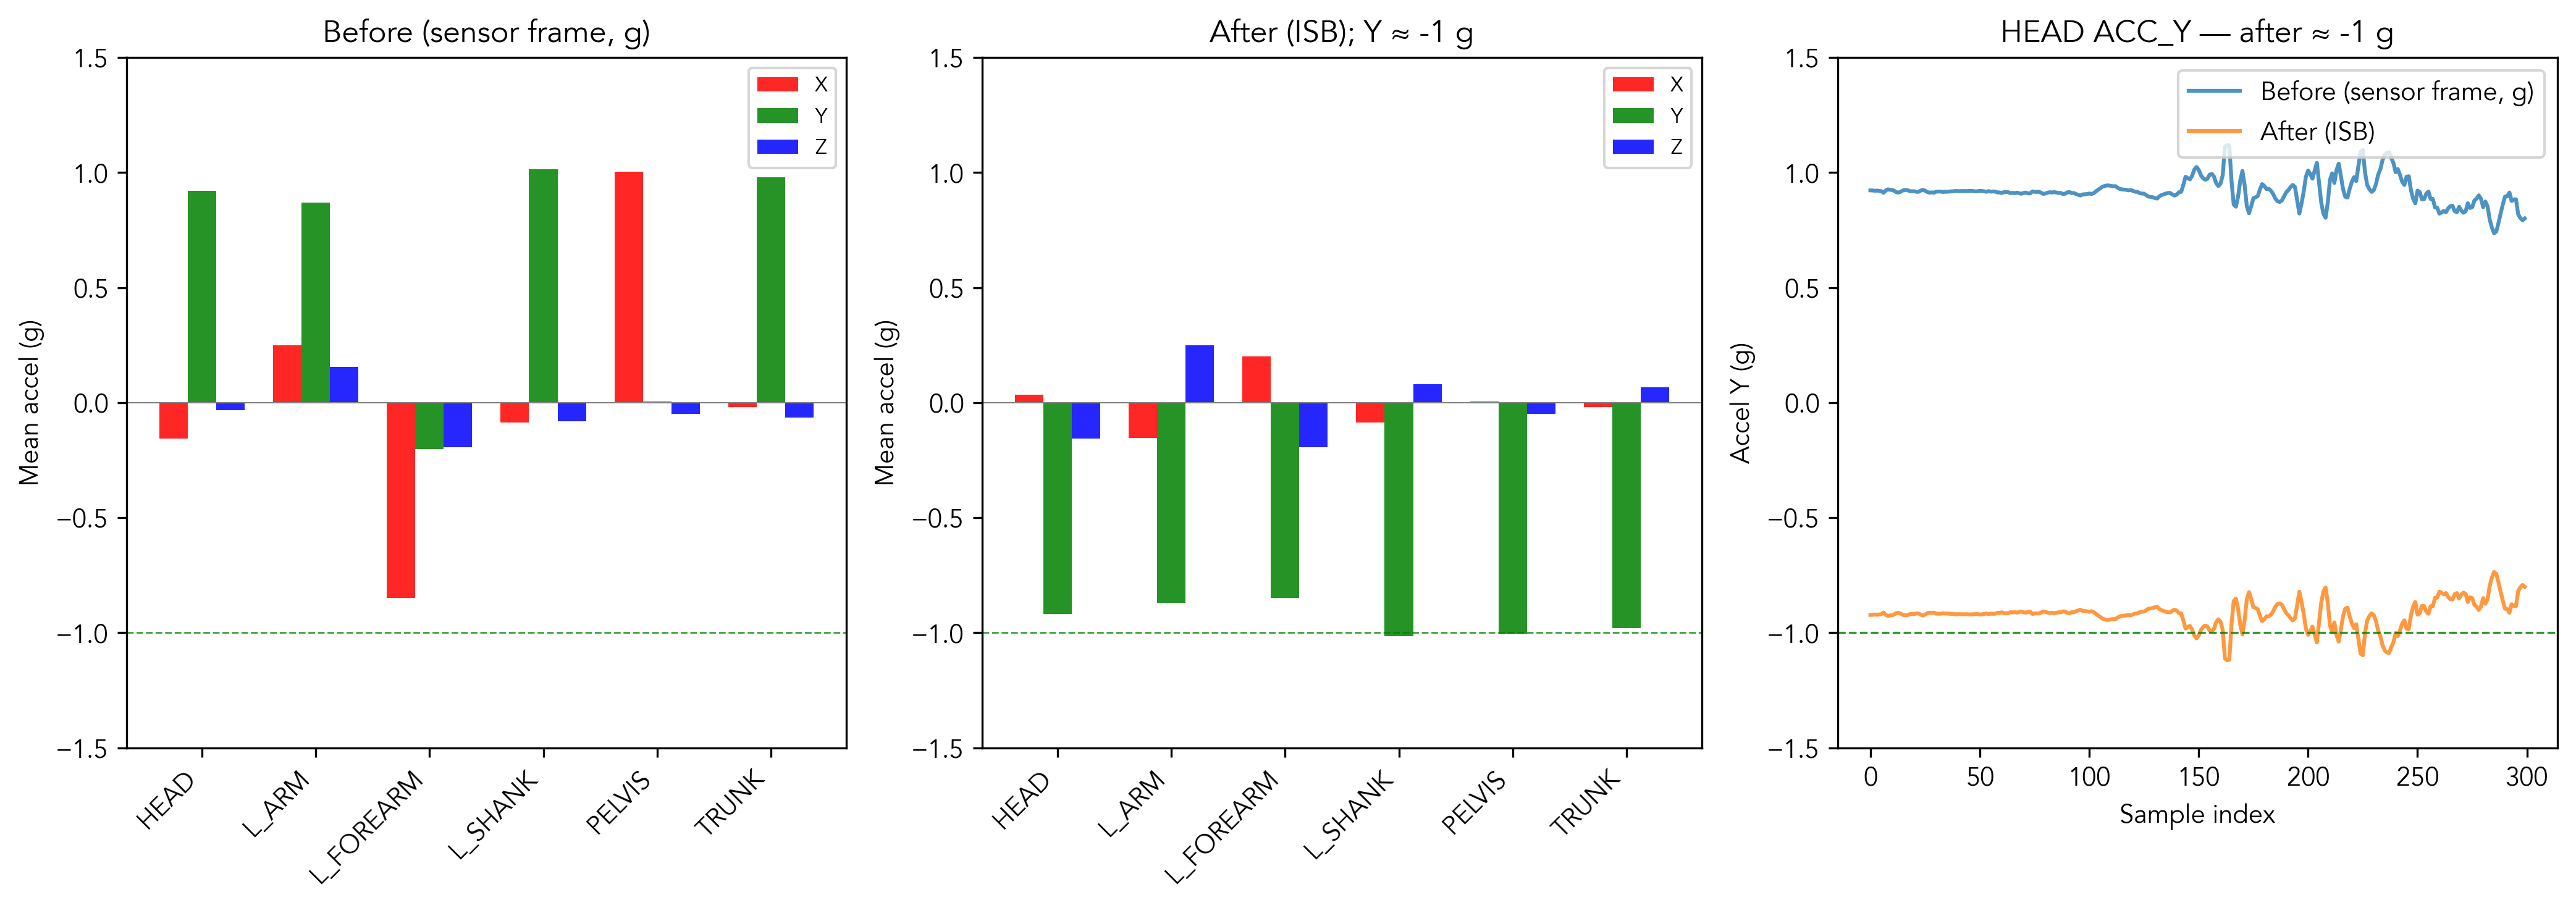

In [599]:
import matplotlib.pyplot as plt

plt.rcParams.dpi = 300
plt.rcParams.font_family = "Avenir"
colors = ['red', 'green', 'blue']
# Recompute "before" (sensor frame, in g) for static window using original df and report scale
sensors = report_df["sensor"].tolist()
axes = ["X", "Y", "Z"]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5), dpi=300)

# --- Panel 1: Mean accel [X,Y,Z] in static — Before (sensor frame) vs After (ISB) ---
mean_before = np.zeros((len(sensors), 3))
mean_after = np.zeros((len(sensors), 3))
for i, s in enumerate(sensors):
    row = report_df[report_df["sensor"] == s].iloc[0]
    ws, we = int(row["static_start"]), int(row["static_end"])
    scale = float(row["scale_to_g"])
    acc_cols = SENSORS[s]["acc"]
    mean_before[i] = (df.loc[ws:we - 1, acc_cols].to_numpy(float) * scale).mean(axis=0)
    mean_after[i] = df_out.loc[ws:we - 1, acc_cols].to_numpy(float).mean(axis=0)

x = np.arange(len(sensors))
w = 0.25
# Left: Before (sensor frame) — gravity direction varies by sensor
for j, (ax_name, jcol) in enumerate(zip(axes, [0, 1, 2])):
    ax1.bar(x + (j - 1) * w, mean_before[:, jcol], w, label=ax_name, alpha=0.85, color=colors[j])
ax1.axhline(0, color="gray", linewidth=0.5)
ax1.axhline(-1, color="green", linestyle="--", linewidth=0.7, alpha=0.7)
ax1.set_xticks(x)
ax1.set_xticklabels(sensors, rotation=45, ha="right")
ax1.set_ylabel("Mean accel (g)")
ax1.set_title("Before (sensor frame, g)")
ax1.legend(loc="upper right", fontsize=8)
ax1.set_ylim(-1.5, 1.5)

# Right: After (ISB) — Y ≈ -1, X and Z ≈ 0 → validation success
for j, (ax_name, jcol) in enumerate(zip(axes, [0, 1, 2])):
    ax2.bar(x + (j - 1) * w, mean_after[:, jcol], w, label=ax_name, alpha=0.85, color=colors[j])
ax2.axhline(0, color="gray", linewidth=0.5)
ax2.axhline(-1, color="green", linestyle="--", linewidth=0.7, alpha=0.7)
ax2.set_xticks(x)
ax2.set_xticklabels(sensors, rotation=45, ha="right")
ax2.set_ylabel("Mean accel (g)")
ax2.set_title("After (ISB); Y ≈ -1 g")
ax2.legend(loc="upper right", fontsize=8)
ax2.set_ylim(-1.5, 1.5)

# --- Panel 3: Time series — one sensor, Y axis (before vs after) ---
example_sensor = sensors[0]
row = report_df[report_df["sensor"] == example_sensor].iloc[0]
ws, we = int(row["static_start"]), int(row["static_end"])
scale = float(row["scale_to_g"])
acc_cols = SENSORS[example_sensor]["acc"]
idx = np.arange(ws, we)
before_y = df.loc[ws:we - 1, acc_cols[1]].to_numpy(float) * scale
after_y = df_out.loc[ws:we - 1, acc_cols[1]].to_numpy(float)
ax3.plot(idx, before_y, alpha=0.8, label="Before (sensor frame, g)", color="C0")
ax3.plot(idx, after_y, alpha=0.8, label="After (ISB)", color="C1")
ax3.axhline(-1, color="green", linestyle="--", linewidth=0.8, alpha=0.8)
ax3.set_xlabel("Sample index")
ax3.set_ylabel("Accel Y (g)")
ax3.set_title(f"{example_sensor} ACC_Y — after ≈ -1 g")
ax3.legend(loc="upper right")
ax3.set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()

In [596]:
sensors = list(rotations.keys())
print(sensors)
print(rotations)


['HEAD', 'L_ARM', 'L_FOREARM', 'L_SHANK', 'PELVIS', 'TRUNK']
{'HEAD': array([[ 0., -1.,  0.],
       [ 1.,  0.,  0.],
       [ 0.,  0.,  1.]]), 'L_ARM': array([[ 0.,  0., -1.],
       [ 0., -1.,  0.],
       [ 1.,  0.,  0.]]), 'L_FOREARM': array([[ 0., -1.,  0.],
       [ 1.,  0.,  0.],
       [ 0.,  0.,  1.]]), 'L_SHANK': array([[ 1.,  0.,  0.],
       [ 0., -1.,  0.],
       [ 0.,  0., -1.]]), 'PELVIS': array([[ 0.,  1.,  0.],
       [-1.,  0.,  0.],
       [ 0.,  0.,  1.]]), 'TRUNK': array([[ 1.,  0.,  0.],
       [ 0., -1.,  0.],
       [ 0.,  0., -1.]])}


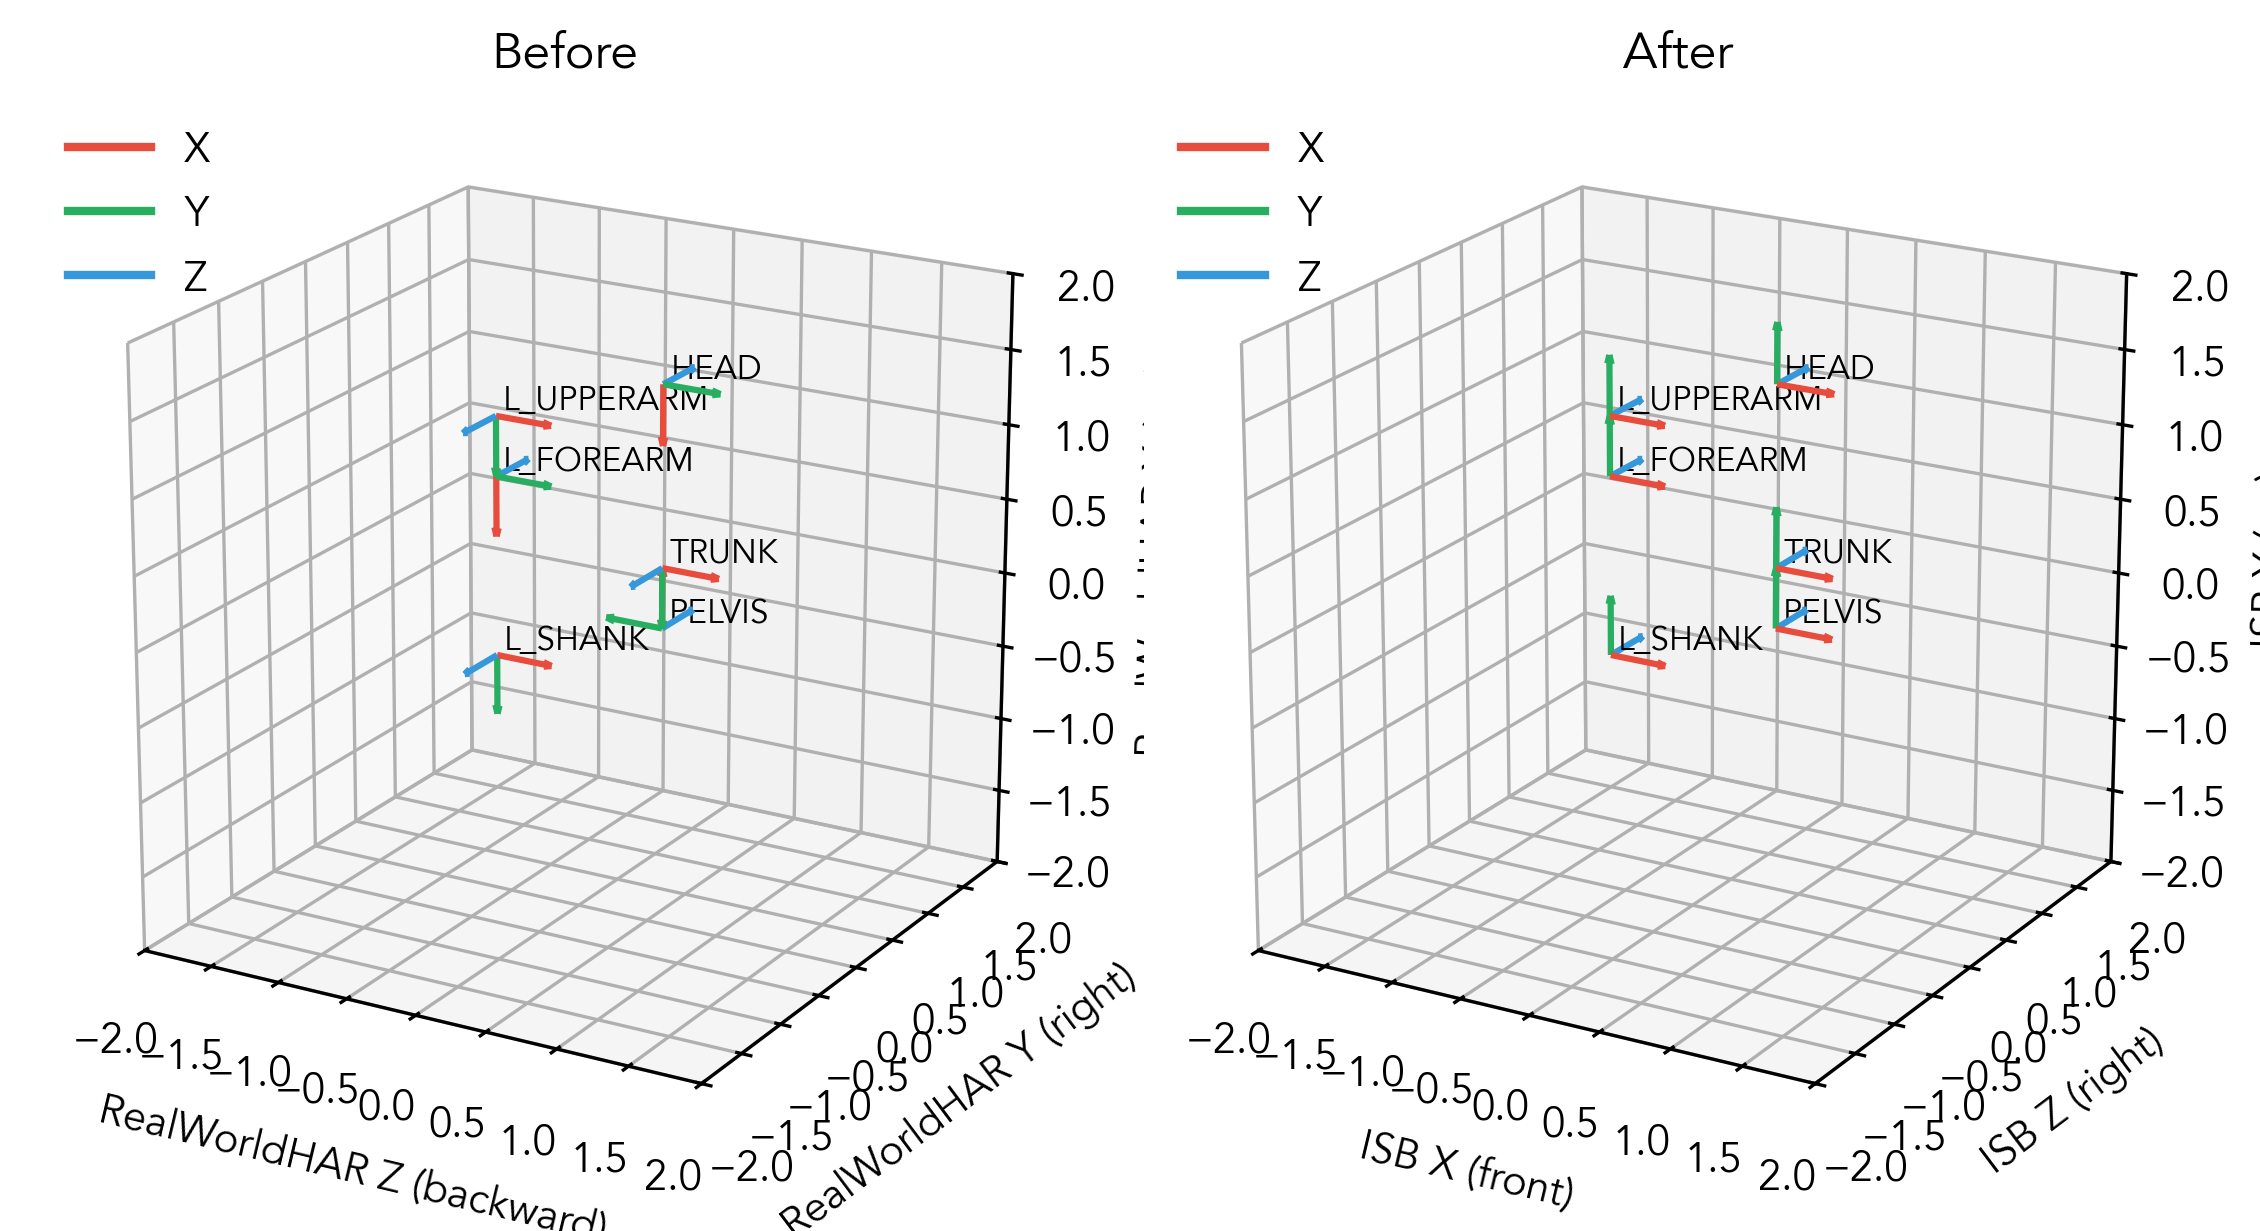

In [589]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Set plotting style
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.family"] = "Avenir"

# rotations[s] is assumed to map:
# sensor frame -> common / ISB-like frame
sensors = list(rotations.keys())

# Place sensors in approximate anatomical positions for visualization.
# px = common X direction
# py = common Y direction (vertical)
# pz = common Z direction
def seg_height(name):
    n = name.upper()
    if "SHANK" in n:
        return -0.4
    if "PELVIS" in n:
        return 0.0
    if "TRUNK" in n:
        return 0.4
    if "FOREARM" in n:
        return 0.8
    if "ARM" in n:
        return 1.2
    if "HEAD" in n:
        return 1.6
    return 0.0

def seg_side(name):
    return -0.6 if name.upper().startswith("L_") else 0.6

positions = np.array([[seg_side(s), seg_height(s), 0.0] for s in sensors])

arrow_scale = 0.4
axis_colors = ["#e74c3c", "#27ae60", "#3498db"]  # X=red, Y=green, Z=blue
axis_names = ["X", "Y", "Z"]

fig = plt.figure(figsize=(15, 5))

# --------------------------------------------------
# Before: original sensor local axes visualized in
# the common / ISB-like reference space.
#
# If rotations[s] maps sensor -> common frame,
# then rotations[s].T represents the original sensor
# basis vectors expressed in the common frame.
# --------------------------------------------------
ax1 = fig.add_subplot(141, projection="3d")

for i, s in enumerate(sensors):
    R_viz = rotations[s].T
    px, py, pz = positions[i]

    for j in range(3):
        dx, dy, dz = arrow_scale * R_viz[:, j]
        ax1.quiver(
            px, pz, py,
            dx, dz, dy,
            color=axis_colors[j],
            arrow_length_ratio=0.15,
            linewidth=1.5
        )

    ax1.text(px + 0.05, pz, py + 0.05, s, fontsize=8)

ax1.set_xlabel("RealWorldHAR Z (backward)")
ax1.set_ylabel("RealWorldHAR Y (right)")
ax1.set_zlabel("RealWorldHAR X (up)")
ax1.set_title("Before")

lim1 = 2.0
ax1.set_xlim(-lim1, lim1)
ax1.set_ylim(-lim1, lim1)
ax1.set_zlim(-lim1, lim1)
ax1.set_box_aspect([1, 1, 1])
ax1.view_init(elev=20, azim=-60)

legend_before = [
    Line2D([0], [0], color=axis_colors[j], lw=2, label=axis_names[j])
    for j in range(3)
]
ax1.legend(handles=legend_before, loc="upper left", frameon=False)

# --------------------------------------------------
# After: all sensors are shown in the same aligned
# common / ISB-like frame.
#
# To make every sensor point in the same final
# direction, use the identity matrix for all sensors.
# --------------------------------------------------
ax2 = fig.add_subplot(142, projection="3d")

R_after = np.eye(3)

for i, s in enumerate(sensors):
    R_viz = R_after
    px, py, pz = positions[i]

    for j in range(3):
        dx, dy, dz = arrow_scale * R_viz[:, j]
        ax2.quiver(
            px, pz, py,
            dx, dz, dy,
            color=axis_colors[j],
            arrow_length_ratio=0.15,
            linewidth=1.5
        )

    ax2.text(px + 0.05, pz, py + 0.05, s, fontsize=8)

ax2.set_xlabel("ISB X (front)")
ax2.set_ylabel("ISB Z (right)")
ax2.set_zlabel("ISB Y (up)")
ax2.set_title("After")

lim2 = 2.0
ax2.set_xlim(-lim2, lim2)
ax2.set_ylim(-lim2, lim2)
ax2.set_zlim(-lim2, lim2)
ax2.set_box_aspect([1, 1, 1])
ax2.view_init(elev=20, azim=-60)

legend_after = [
    Line2D([0], [0], color=axis_colors[j], lw=2, label=axis_names[j])
    for j in range(3)
]
ax2.legend(handles=legend_after, loc="upper left", frameon=False)

plt.tight_layout()
plt.show()

## extra take out later ##
R_HEAD = np.array([
    [0, -1, 0],
    [1,  0, 0],
    [0,  0, 1]
], dtype=float)
R_FOREARM = np.array([
    [1, 0,  0],
    [0, 0, -1],
    [0, 1,  0]
], dtype=float)
R_SHANK = np.array([
    [1, 0, 0],
    [0, 0, 1],
    [0,-1, 0]
], dtype=float)
R_UPPERARM = np.array([
    [0, -1, 0],
    [1,  0, 0],
    [0,  0, 1]
], dtype=float)
R_PELVIS = np.array([
    [1, 0,  0],
    [0, 0, -1],
    [0, 1,  0]
], dtype=float)
R_TRUNK = np.array([
    [0, -1, 0],
    [1,  0, 0],
    [0,  0, 1]
], dtype=float)
## end ##